## 2. Initial Data Inspection

This section examines the dataset structure, including the number of observations, features, data types, missing values, and target class distribution.

In [59]:

import pandas as pd

df = pd.read_csv("customer_booking.csv", encoding="latin1")

df.head()



,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [60]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Number of rows: 50000
Number of columns: 14

Column names:
['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete']

Data types:
num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object


In [61]:

print("Missing values:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df["booking_complete"].value_counts())

print("\nTarget percentages:")
print(df["booking_complete"].value_counts(normalize=True) * 100)


Missing values:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

Target variable distribution:
booking_complete
0    42522
1     7478
Name: count, dtype: int64

Target percentages:
booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64


### Initial Data Inspection — Key Findings

The dataset contains 50,000 records and 14 columns, including 13 input features and one binary target variable (`booking_complete`).

The missing value analysis shows that there are no missing values in any of the columns.

The target variable has two classes:
- Class 0 (Incomplete Booking): 42,522 records (85.04%).
- Class 1 (Completed Booking): 7,478 records (14.96%).

The dataset shows a clear class imbalance, with incomplete bookings representing the majority of records. This imbalance should be considered when evaluating classification models, as accuracy alone may not adequately reflect their performance.

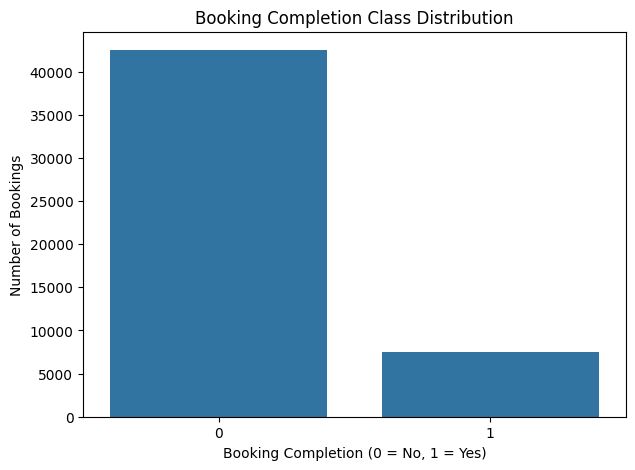

In [62]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="booking_complete",
    order=[0, 1]
)

plt.title("Booking Completion Class Distribution")
plt.xlabel("Booking Completion (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")

plt.show()


### Interpretation: Booking Completion Class Distribution

The chart shows a significant class imbalance in the dataset. Out of 50,000 booking records, 42,522 (85.04%) are incomplete bookings, while only 7,478 (14.96%) are completed bookings.

This indicates that the majority of booking records belong to Class 0. Therefore, classification models should be evaluated using metrics such as Precision, Recall, F1-Score, and ROC-AUC rather than relying only on Accuracy.

## Descriptive Statistics

This section summarizes the numerical features using statistical measures such as mean, standard deviation, minimum, maximum, and quartiles.

In [63]:

# Statistical summary of numerical features

df.describe().T


,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0


### Interpretation: Descriptive Statistics

The descriptive statistics provide an overview of the numerical features in the airline booking dataset.

The average number of passengers per booking is approximately 1.59, with a median of 1. The average purchase lead time is 84.94 days, while the average length of stay is 23.04 days.

The maximum purchase lead time (867 days) and length of stay (778 days) are considerably higher than their respective medians (51 and 17 days). This suggests positively skewed distributions and potential outliers that require further investigation.

Regarding additional services, approximately 66.88% of booking records indicate a preference for extra baggage, 29.70% for preferred seats, and 42.71% for in-flight meals.

Overall, the statistical summary highlights variations in booking characteristics and identifies potential outliers that should be examined during preprocessing.

## Feature Distributions

This section explores the distributions of numerical booking features using histograms and box plots.

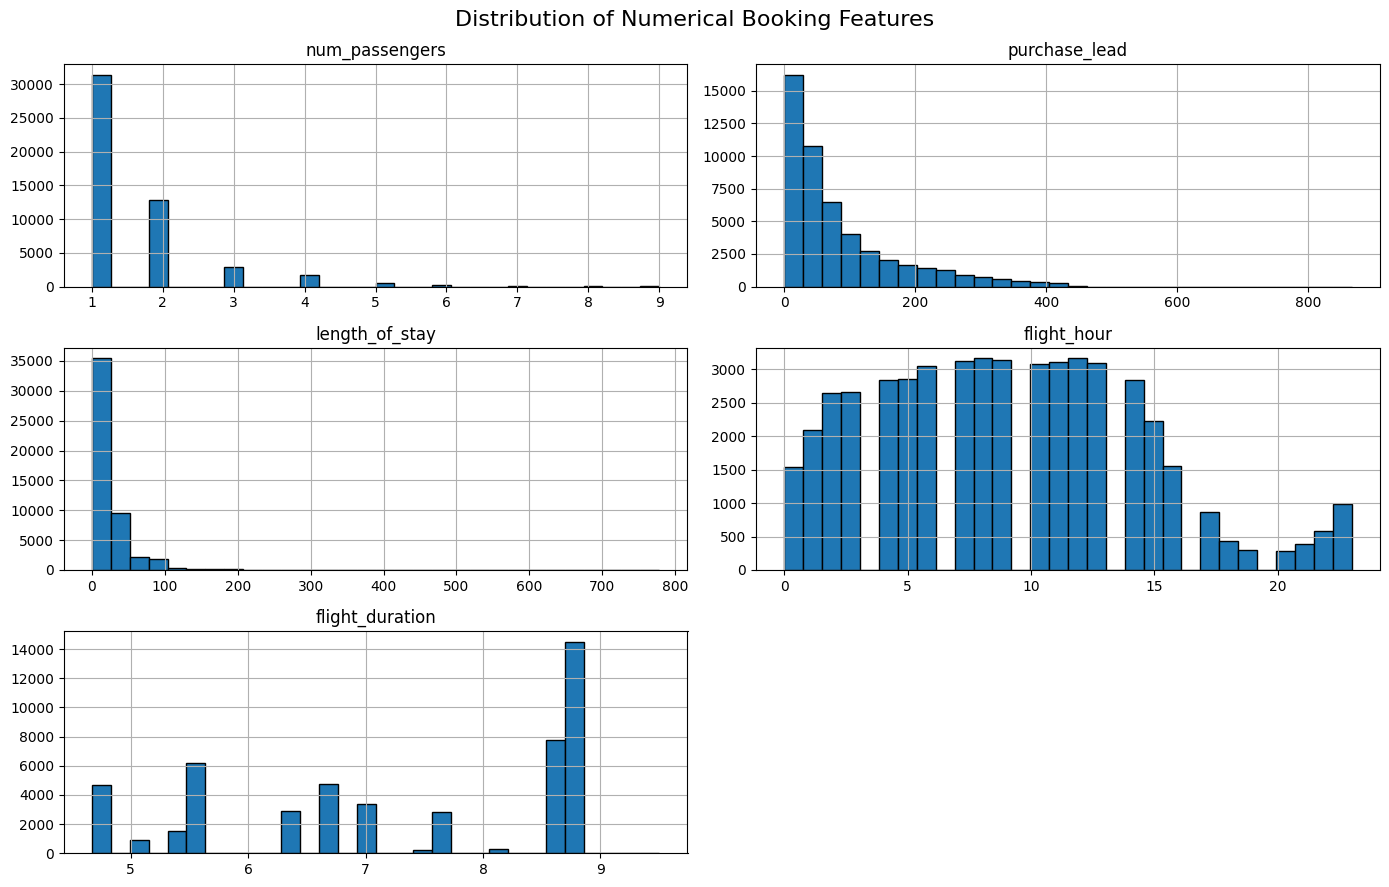

In [64]:

import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration"
]

df[numerical_features].hist(
    bins=30,
    figsize=(14, 9),
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Booking Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


### Interpretation: Numerical Feature Distributions

The histograms illustrate the distribution of five numerical booking features.

- **Number of Passengers:** Most booking records involve one passenger, while bookings with larger groups are less frequent.

- **Purchase Lead Time:** The distribution is positively skewed, indicating that shorter booking lead times are more common. A small number of records have exceptionally long lead times.

- **Length of Stay:** The distribution is strongly right-skewed, with most records showing relatively short stays and a small number showing unusually long stays.

- **Flight Hour:** Flight times are distributed across the day, with relatively higher frequencies during some morning and midday hours.

- **Flight Duration:** The distribution shows several distinct peaks, suggesting that certain flight durations occur more frequently than others.

Overall, the histograms reveal skewed distributions and potentially extreme values, particularly in purchase lead time and length of stay. These observations should be examined during the preprocessing stage.

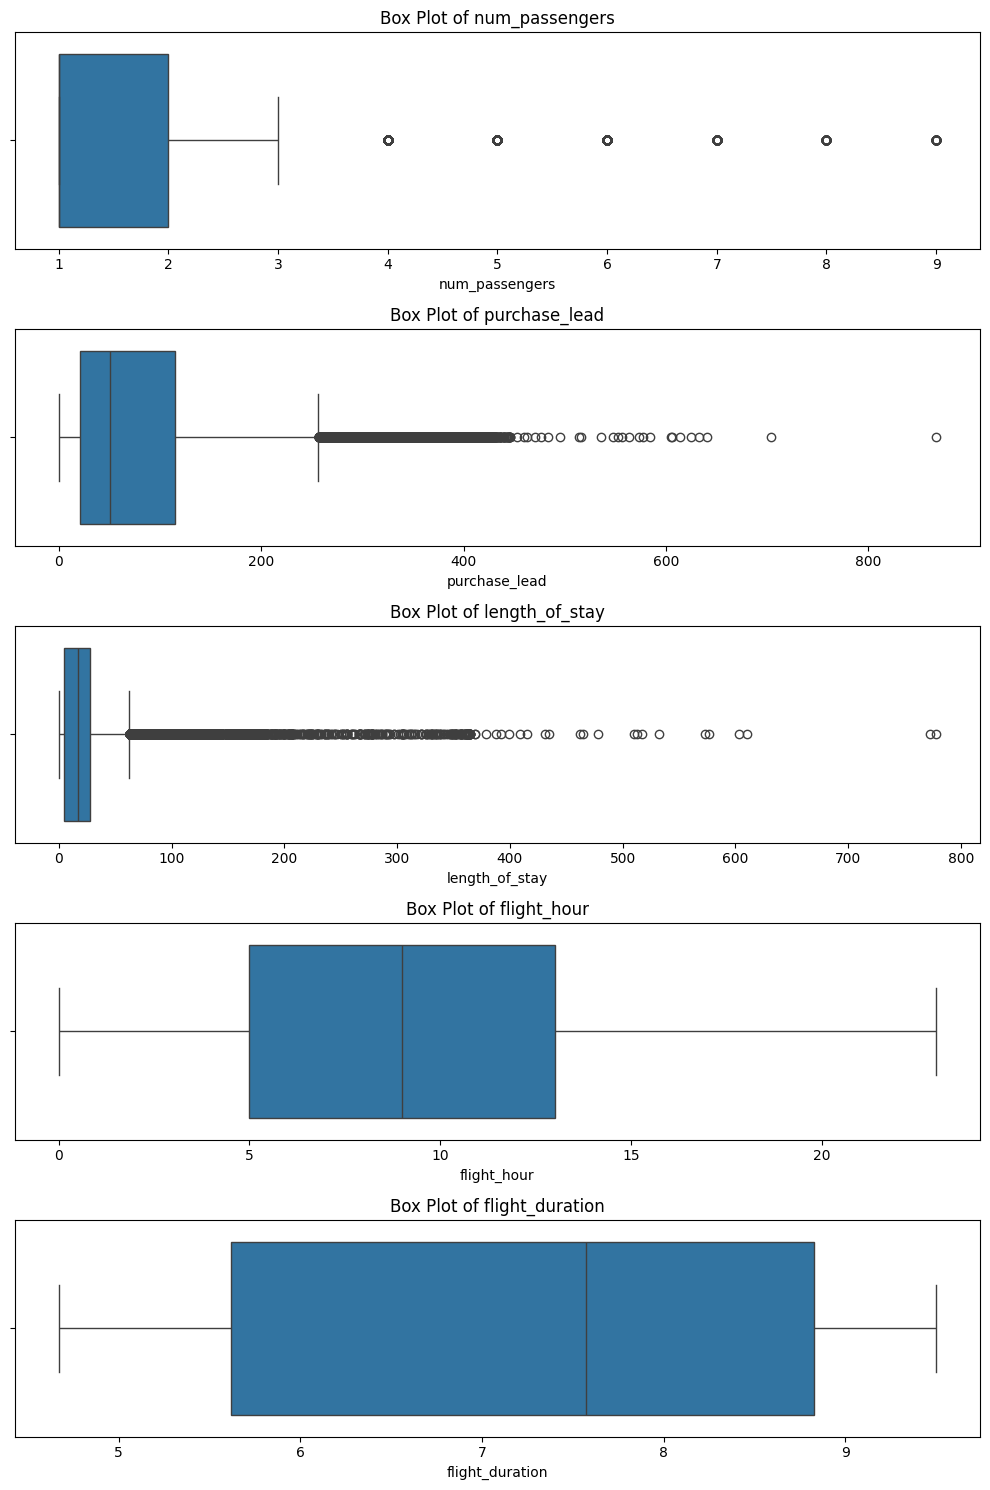

In [65]:

import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration"
]

fig, axes = plt.subplots(5, 1, figsize=(10, 15))

for i, feature in enumerate(features):
    sns.boxplot(
        x=df[feature],
        ax=axes[i]
    )
    axes[i].set_title(f"Box Plot of {feature}")
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()


### Interpretation: Box Plots and Potential Outliers

The box plots reveal differences in the spread of numerical booking features.

- **Number of Passengers:** Most bookings involve one or two passengers. Values between 4 and 9 appear as potential outliers based on the box plot's statistical criteria.
- **Purchase Lead Time:** The distribution contains numerous high-value outliers, reaching a maximum of 867 days.
- **Length of Stay:** Several extreme values are observed, with a maximum stay of 778 days.
- **Flight Hour:** The values range from 0 to 23, with no apparent outliers.
- **Flight Duration:** The values range from 4.67 to 9.5 hours, with no apparent outliers.

Overall, purchase lead time and length of stay show substantial positive skewness and numerous potential outliers. These values should be investigated during preprocessing rather than automatically removed, since they may represent valid booking records.

## Feature vs. Target Analysis

This section examines how booking completion rates vary across different booking characteristics and passenger preferences.

sales_channel
Internet    15.476995
Mobile      10.840157
Name: booking_complete, dtype: float64


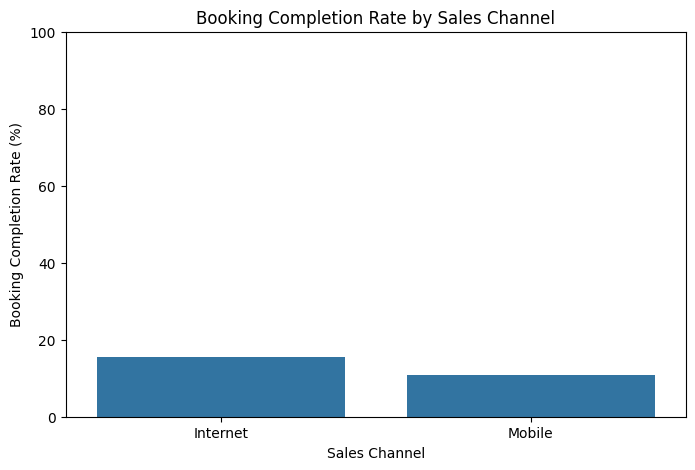

In [66]:

# Booking completion rate by sales channel

completion_by_channel = (
    df.groupby("sales_channel")["booking_complete"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(completion_by_channel)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=completion_by_channel.index,
    y=completion_by_channel.values
)

plt.title("Booking Completion Rate by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Booking Completion Rate (%)")
plt.ylim(0, 100)

plt.show()


### Interpretation: Booking Completion Rate by Sales Channel

The chart shows that booking completion rates differ between the two sales channels.

Bookings made through the Internet have a completion rate of approximately 15.48%, compared to 10.84% for Mobile bookings.

This indicates that Internet bookings are associated with a higher completion rate, with a difference of approximately 4.64 percentage points.

From a commercial perspective, this finding may help the CCO identify opportunities to investigate the mobile booking experience. However, the observed relationship does not establish that the sales channel directly causes the difference in completion rates.

trip_type
RoundTrip     15.057478
OneWay         5.167959
CircleTrip     4.310345
Name: booking_complete, dtype: float64


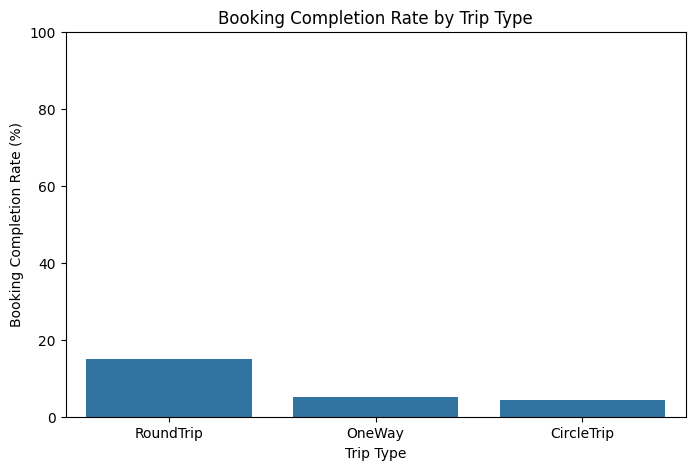

In [67]:

# Booking completion rate by trip type

completion_by_trip = (
    df.groupby("trip_type")["booking_complete"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(completion_by_trip)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=completion_by_trip.index,
    y=completion_by_trip.values
)

plt.title("Booking Completion Rate by Trip Type")
plt.xlabel("Trip Type")
plt.ylabel("Booking Completion Rate (%)")
plt.ylim(0, 100)

plt.show()


### Interpretation: Booking Completion Rate by Trip Type

The chart shows differences in booking completion rates across trip types.

RoundTrip bookings have the highest completion rate at approximately 15.06%, followed by OneWay bookings at 5.17% and CircleTrip bookings at 4.31%.

This suggests that trip type is associated with booking completion in the dataset. RoundTrip bookings are more likely to be completed than the other trip types in the observed records.

However, these findings represent associations rather than causal relationships. The differences may also be influenced by other booking characteristics.

## Correlation Analysis

This section shows the correlations between numerical features and booking completion.

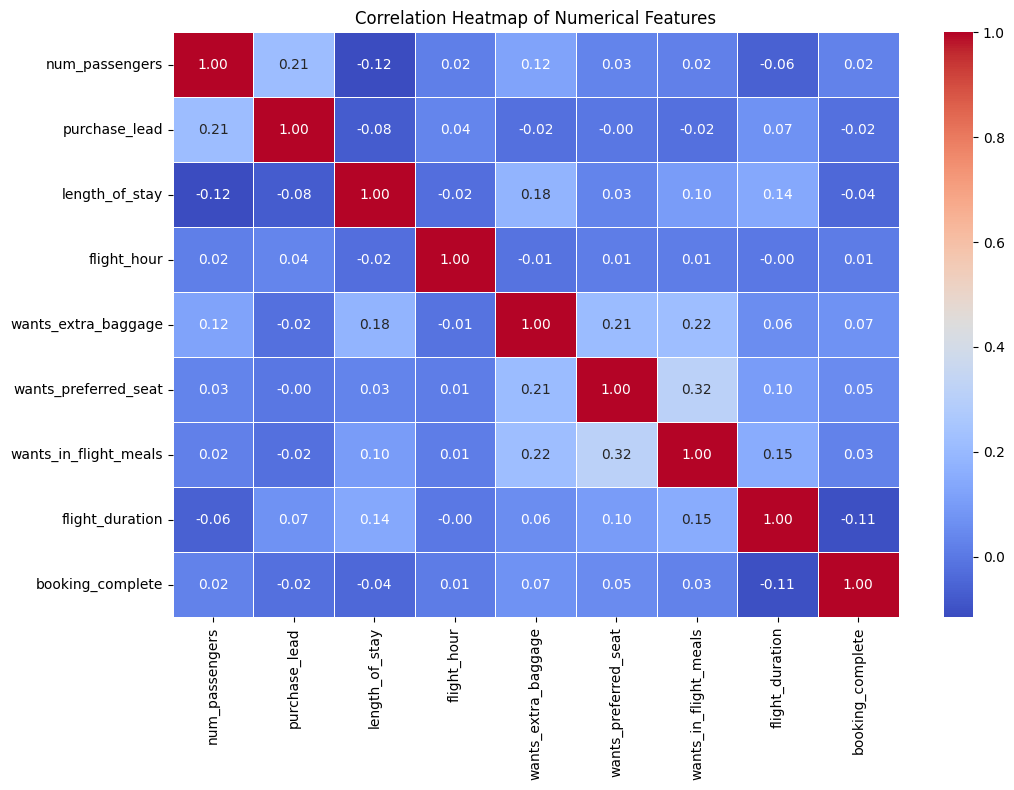

In [68]:

# Correlation heatmap for numerical features

numerical_df = df.select_dtypes(include=["number"])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### Interpretation: Correlation Heatmap

The correlation heatmap illustrates the linear relationships among the numerical features and the target variable (`booking_complete`).

Most numerical features show weak linear correlations with booking completion. Flight duration has the strongest negative correlation with the target (approximately -0.11), while extra baggage preference shows a weak positive correlation (approximately 0.07).

Among the input features, preferred seat selection and in-flight meal preference show a positive correlation of approximately 0.32.

Overall, the results suggest that no single numerical feature has a strong linear relationship with booking completion. However, weak individual correlations do not necessarily imply low predictive value, as machine learning models may capture nonlinear relationships and interactions between features.

Additionally, categorical variables such as sales channel, trip type, and booking origin are not included in this numerical correlation matrix and should be analyzed separately.

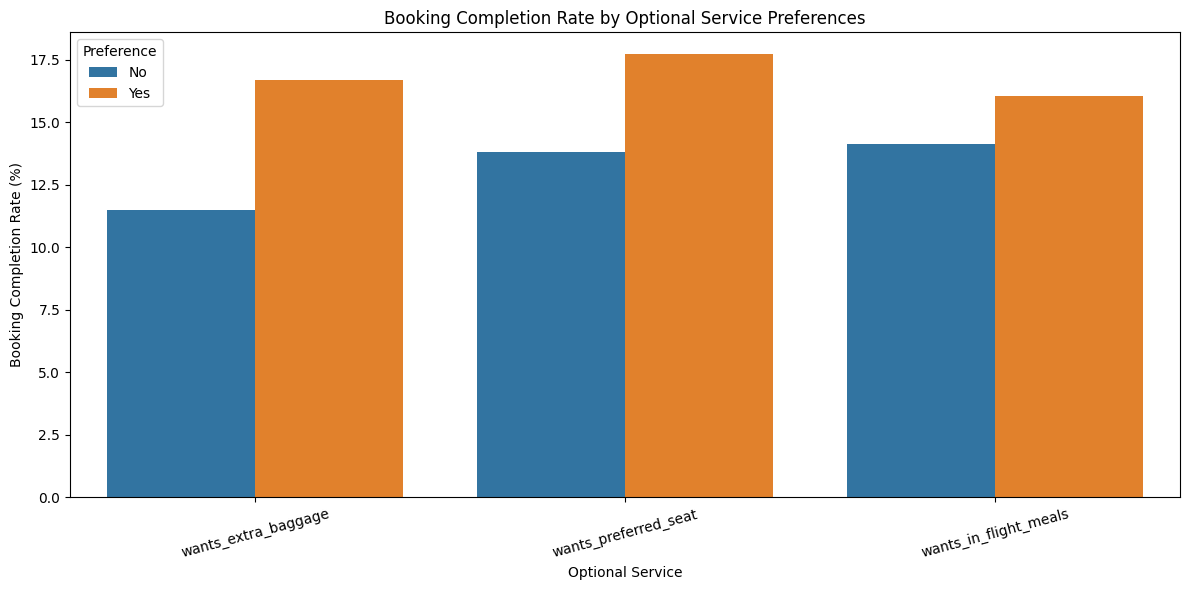

                 Service Preference  Completion Rate
0    wants_extra_baggage         No        11.502929
1    wants_extra_baggage        Yes        16.666168
2   wants_preferred_seat         No        13.794379
3   wants_preferred_seat        Yes        17.706088
4  wants_in_flight_meals         No        14.139580
5  wants_in_flight_meals        Yes        16.050943


In [69]:

# Booking completion rate by optional service preferences

services = [
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals"
]

service_results = []

for service in services:
    rates = df.groupby(service)["booking_complete"].mean() * 100

    for preference, rate in rates.items():
        service_results.append({
            "Service": service,
            "Preference": "Yes" if preference == 1 else "No",
            "Completion Rate": rate
        })

service_df = pd.DataFrame(service_results)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=service_df,
    x="Service",
    y="Completion Rate",
    hue="Preference"
)

plt.title("Booking Completion Rate by Optional Service Preferences")
plt.xlabel("Optional Service")
plt.ylabel("Booking Completion Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(service_df)


### Interpretation: Booking Completion Rate by Optional Service Preferences

The chart shows that booking records with additional service preferences have higher completion rates.

Extra baggage selection is associated with a completion rate of 16.67%, compared to 11.50% without extra baggage. Preferred seat selection shows rates of 17.71% versus 13.79%, while in-flight meal selection shows rates of 16.05% versus 14.14%.

The largest difference is observed for extra baggage preference. However, these relationships are associations and do not establish that selecting additional services causes higher booking completion.

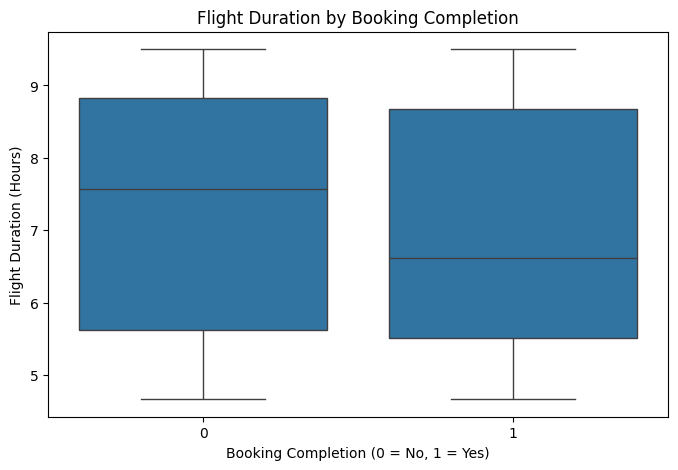

In [70]:

# Flight duration vs booking completion

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="booking_complete",
    y="flight_duration"
)

plt.title("Flight Duration by Booking Completion")
plt.xlabel("Booking Completion (0 = No, 1 = Yes)")
plt.ylabel("Flight Duration (Hours)")

plt.show()


### Interpretation: Flight Duration vs. Booking Completion

The box plot compares flight duration distributions between completed and incomplete bookings.

Completed bookings have a lower median flight duration (approximately 6.6 hours) compared to incomplete bookings (approximately 7.6 hours).

However, the distributions overlap considerably, suggesting that flight duration alone cannot clearly distinguish between completed and incomplete bookings.

This observation is consistent with the weak negative correlation (approximately -0.11) between flight duration and booking completion shown in the correlation heatmap.

Overall, flight duration may provide useful information for the classification model when combined with other booking characteristics, although the observed relationship does not establish causation.